# MLPRouter - Training

This notebook demonstrates how to train the **MLPRouter** (Multi-Layer Perceptron Router).

## Overview

MLPRouter uses a neural network classifier with multiple hidden layers to route queries.

**Key Features**:
- Can learn complex non-linear decision boundaries
- Flexible architecture with configurable layers
- Good for large-scale routing problems

## 1. Environment Setup

In [1]:
# Install required packages (for Colab)
!git clone https://github.com/ulab-uiuc/LLMRouter.git
%cd LLMRouter
!pip install -e .
!pip install transformers torch


fatal: destination path 'LLMRouter' already exists and is not an empty directory.
/home/zhongjie/LLMRouter
Obtaining file:///home/zhongjie/LLMRouter
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Using cached transformers-4.57.6-py3-none-any.whl.metadata (43 kB)
  Using cached sentencepiece-0.2.1-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (10 kB)
  Using cached datasets-4.5.0-py3-none-any.whl.metadata (19 kB)
  Using cached gradio-6.3.0-py3-none-any.whl.metadata (16 kB)
  Using cached litellm-1.81.0-py3-none-any.whl.metadata (29 kB)
  Using cached peft-0.18.1-py3-none-any.whl.metadata (14 kB)
  Using cached torch_geometric-2.7.0-py3-none-any.whl.metadata (63 kB)
  Using cached xxhash-3.6.0-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (13 kB)
  Using cached

In [3]:
import os
os.environ['OPENAI_API_KEY'] = 'your-key'
os.environ['ANTHROPIC_API_KEY'] = 'your-key'
# Or for multiple keys:
os.environ['API_KEYS'] = '["key1", "key2"]'

In [3]:
from llmrouter.models.mlprouter import MLPRouter, MLPTrainer
from llmrouter.utils import setup_environment

setup_environment()
print("Environment setup complete!")

Environment setup complete!


## 2. Configuration

MLPRouter uses the following configuration parameters:

| Parameter | Description | Default |
|-----------|-------------|--------|
| `hidden_layer_sizes` | Neurons in each hidden layer | [128, 64] |
| `activation` | Activation function | "relu" |
| `solver` | Optimizer: "adam", "lbfgs", "sgd" | "adam" |
| `alpha` | L2 regularization | 0.0001 |
| `learning_rate` | Learning rate schedule | "adaptive" |
| `max_iter` | Maximum iterations | 500 |

In [4]:
import yaml

CONFIG_PATH = "configs/model_config_train/mlprouter.yaml"

with open(CONFIG_PATH, 'r') as f:
    config = yaml.safe_load(f)

print("Current Configuration:")
print("=" * 50)
print(yaml.dump(config, default_flow_style=False))

Current Configuration:
api_endpoint: https://integrate.api.nvidia.com/v1
data_path:
  llm_data: data/example_data/llm_candidates/default_llm.json
  llm_embedding_data: data/example_data/llm_candidates/default_llm_embeddings.json
  query_data_test: data/example_data/query_data/default_query_test.jsonl
  query_data_train: data/example_data/query_data/default_query_train.jsonl
  query_embedding_data: data/example_data/routing_data/query_embeddings_longformer.pt
  routing_data_test: data/example_data/routing_data/default_routing_test_data.jsonl
  routing_data_train: data/example_data/routing_data/default_routing_train_data.jsonl
hparam:
  activation: relu
  alpha: 0.0001
  batch_size: 32
  epochs: 100
  hidden_layer_sizes:
  - 128
  - 64
  lr: 0.001
metric:
  weights:
    cost: 0
    llm_judge: 0
    performance: 1
model_path:
  ini_model_path: ''
  save_model_path: saved_models/mlprouter/mlprouter.pkl



## 3. Initialize Router

In [5]:
router = MLPRouter(yaml_path=CONFIG_PATH)

print("Router initialized successfully!")
print(f"Number of training samples: {len(router.routing_data_train)}")
print(f"Number of LLM candidates: {len(router.llm_data)}")
print(f"LLM candidates: {list(router.llm_data.keys())}")

✅ MetaRouter initialized successfully (YAML + data loaded).
Router initialized successfully!
Number of training samples: 50544
Number of LLM candidates: 7
LLM candidates: ['qwen2.5-7b-instruct', 'llama-3.1-8b-instruct', 'mistral-7b-instruct-v0.3', 'llama-3.3-nemotron-super-49b-v1', 'llama3-70b-instruct', 'mixtral-8x7b-instruct-v0.1', 'mixtral-8x22b-instruct-v0.1']


In [6]:
# Inspect MLP architecture
print("MLP Model Parameters:")
print(f"  Input dimension: {router.mlp_model.layers[0].in_features}")
print(f"  Hidden layers: {[layer.out_features for layer in router.mlp_model.layers[:-1]]}")
print(f"  Output features: {router.mlp_model.layers[-1].out_features}")
print(f"  Activation: {router.mlp_model.activation_name}")
print(f"  Total parameters: {sum(p.numel() for p in router.mlp_model.parameters())}")


MLP Model Parameters:
  Input dimension: 768
  Hidden layers: [128, 64]
  Output features: 9
  Activation: relu
  Total parameters: 107273


## 4. Training

In [7]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
trainer = MLPTrainer(router=router, device=device)

print("Trainer initialized!")
print(f"Training samples: {len(trainer.query_embeddings)}")
print(f"Save path: {trainer.save_model_path}")

[MLPTrainer] Initialized on device: cuda
[MLPTrainer] Model: [128, 64], lr=0.001, epochs=100, batch_size=32
Trainer initialized!
Training samples: 5608
Save path: /home/zhongjie/LLMRouter/llmrouter/saved_models/mlprouter/mlprouter.pkl


In [8]:
print("Starting training...")
print("=" * 50)

trainer.train()

print("=" * 50)
print("Training completed!")

Starting training...
[MLPTrainer] Epoch 10/100 - Loss=1.240885, Accuracy=0.5851
[MLPTrainer] Epoch 20/100 - Loss=1.028582, Accuracy=0.6471
[MLPTrainer] Epoch 30/100 - Loss=0.746673, Accuracy=0.7734
[MLPTrainer] Epoch 40/100 - Loss=0.473416, Accuracy=0.8764
[MLPTrainer] Epoch 50/100 - Loss=0.304272, Accuracy=0.9331
[MLPTrainer] Epoch 60/100 - Loss=0.202495, Accuracy=0.9574
[MLPTrainer] Epoch 70/100 - Loss=0.139151, Accuracy=0.9437
[MLPTrainer] Epoch 80/100 - Loss=0.126454, Accuracy=0.9579
[MLPTrainer] Epoch 90/100 - Loss=0.136906, Accuracy=0.9626
[MLPTrainer] Epoch 100/100 - Loss=0.102195, Accuracy=0.9782
Successfully saved pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/mlprouter/mlprouter.pkl
[MLPTrainer] Model saved to /home/zhongjie/LLMRouter/llmrouter/saved_models/mlprouter/mlprouter.pkl
[MLPTrainer] Loss history saved to /home/zhongjie/LLMRouter/llmrouter/saved_models/mlprouter/mlprouter_loss.json
Training completed!


## 5. Model Verification

In [9]:
from llmrouter.utils import load_model
import numpy as np

saved_model = load_model(trainer.save_model_path)

print("Model loaded successfully!")
print(f"Model type: {type(saved_model).__name__}")
print(f"Keys: {list(saved_model.keys())}")
print(f"Number of layers: {len([k for k in saved_model.keys() if k.startswith('layers.')])}")

Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/mlprouter/mlprouter.pkl
Model loaded successfully!
Model type: OrderedDict
Keys: ['layers.0.weight', 'layers.0.bias', 'layers.1.weight', 'layers.1.bias', 'layers.2.weight', 'layers.2.bias']
Number of layers: 6


In [10]:
# Quick prediction test
test_embedding = trainer.query_embeddings[0].unsqueeze(0)

router.mlp_model.eval()
with torch.no_grad():
    logits = router.mlp_model(test_embedding)
    proba = torch.softmax(logits, dim=1).numpy()[0]
    pred_idx = torch.argmax(logits, dim=1).item()

prediction = router.idx_to_model[pred_idx]
print(f"Test prediction: {prediction}")

print(f"\nPrediction probabilities:")
for idx, prob in enumerate(proba):
    model_name = router.idx_to_model[idx]
    print(f"  {model_name}: {prob:.4f}")


Test prediction: llama3-chatqa-1.5-70b

Prediction probabilities:
  llama-3.1-8b-instruct: 0.1218
  qwen2.5-7b-instruct: 0.1084
  gemma-2-9b-it: 0.0915
  mistral-7b-instruct-v0.3: 0.1081
  llama3-chatqa-1.5-8b: 0.0948
  codegemma-7b: 0.1093
  llama-3.3-nemotron-super-49b-v1: 0.1240
  llama3-chatqa-1.5-70b: 0.1461
  llama-3.1-nemotron-51b-instruct: 0.0959


## 6. Learning Curve Analysis

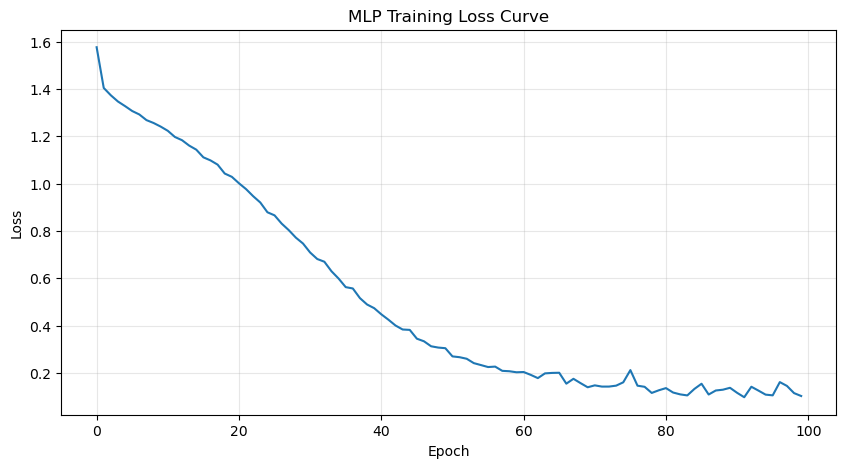

In [11]:
import matplotlib.pyplot as plt
import json
import os

loss_path = trainer.save_model_path.replace('.pth', '_loss.json').replace('.pkl', '_loss.json')

if os.path.exists(loss_path):
    with open(loss_path, 'r') as f:
        loss_history = json.load(f)

    plt.figure(figsize=(10, 5))
    plt.plot(loss_history)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('MLP Training Loss Curve')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Loss history not found. Run training again with updated trainer.")


## 7. Architecture Comparison

In [12]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import KFold
from llmrouter.models.mlprouter.router import MLPClassifierNN

X_np = trainer.query_embeddings.numpy()
y_np = trainer.label_indices.numpy()
X_tensor = torch.FloatTensor(X_np)
y_tensor = torch.LongTensor(y_np)

architectures = [
    [64],
    [128],
    [128, 64],
    [256, 128],
    [256, 128, 64],
]

print("Architecture comparison:")
print("=" * 50)

results = []
for arch in architectures:
    fold_scores = []
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    
    for train_idx, val_idx in kf.split(X_tensor):
        X_train, X_val = X_tensor[train_idx], X_tensor[val_idx]
        y_train, y_val = y_tensor[train_idx], y_tensor[val_idx]
        
        model = MLPClassifierNN(
            input_dim=X_np.shape[1],
            hidden_layer_sizes=arch,
            num_classes=len(np.unique(y_np)),
            activation="relu"
        )
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        criterion = nn.CrossEntropyLoss()
        
        model.train()
        for _ in range(50):
            optimizer.zero_grad()
            outputs = model(X_train)
            loss = criterion(outputs, y_train)
            loss.backward()
            optimizer.step()
        
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val)
            _, predicted = torch.max(val_outputs, 1)
            acc = (predicted == y_val).float().mean().item()
            fold_scores.append(acc)
    
    mean_score = np.mean(fold_scores)
    std_score = np.std(fold_scores)
    results.append((arch, mean_score, std_score))
    print(f"{str(arch):20} Accuracy: {mean_score:.4f} (+/- {std_score:.4f})")

best_arch, best_score, _ = max(results, key=lambda x: x[1])
print(f"\nBest architecture: {best_arch} with accuracy: {best_score:.4f}")


Architecture comparison:
[64]                 Accuracy: 0.5098 (+/- 0.0034)
[128]                Accuracy: 0.5200 (+/- 0.0057)
[128, 64]            Accuracy: 0.5114 (+/- 0.0071)
[256, 128]           Accuracy: 0.5212 (+/- 0.0033)
[256, 128, 64]       Accuracy: 0.5100 (+/- 0.0108)

Best architecture: [256, 128] with accuracy: 0.5212


## Summary

In this notebook, we:

1. **Loaded Configuration**: Set up MLPRouter with YAML configuration
2. **Trained Model**: Used MLPRouterTrainer to fit the neural network
3. **Verified Model**: Loaded and tested the saved model
4. **Compared Architectures**: Found optimal layer configuration

**Next Steps**:
- Use the next part of notebook for inference
- Experiment with different activation functions

# MLPRouter - Inference

This part of notebook demonstrates how to use a trained **MLPRouter** for inference.

## 1. Environment Setup (optional)

In [13]:
from llmrouter.models.mlprouter import MLPRouter
from llmrouter.utils import setup_environment, load_model, get_longformer_embedding
import yaml

setup_environment()

## 2. Load Trained Router

In [14]:
CONFIG_PATH = "configs/model_config_train/mlprouter.yaml"

with open(CONFIG_PATH, 'r') as f:
    config = yaml.safe_load(f)

config['model_path']['load_model_path'] = config['model_path']['save_model_path']

INFERENCE_CONFIG_PATH = "configs/model_config_test/mlprouter_inference.yaml"
os.makedirs(os.path.dirname(INFERENCE_CONFIG_PATH), exist_ok=True)

with open(INFERENCE_CONFIG_PATH, 'w') as f:
    yaml.dump(config, f)

router = MLPRouter(yaml_path=INFERENCE_CONFIG_PATH)
print(f"Router loaded with {len(router.llm_data)} LLM candidates")

✅ MetaRouter initialized successfully (YAML + data loaded).
Router loaded with 7 LLM candidates


## 3. Single Query Routing

In [15]:
EXAMPLE_QUERIES = [
    {"query": "What is the capital of France?"},
    {"query": "Solve the equation: 2x + 5 = 15"},
    {"query": "Write a Python function to check if a number is prime."},
    {"query": "Explain quantum computing in simple terms."},
]

print("Routing Results:")
print("=" * 60)

for i, query in enumerate(EXAMPLE_QUERIES, 1):
    result = router.route_single(query)
    print(f"{i}. {query['query'][:50]}...")
    print(f"   Routed to: {result['model_name']}")

Routing Results:
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/mlprouter/mlprouter.pkl


Input ids are automatically padded to be a multiple of `config.attention_window`: 512


1. What is the capital of France?...
   Routed to: gemma-2-9b-it
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/mlprouter/mlprouter.pkl
2. Solve the equation: 2x + 5 = 15...
   Routed to: qwen2.5-7b-instruct
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/mlprouter/mlprouter.pkl
3. Write a Python function to check if a number is pr...
   Routed to: llama-3.1-8b-instruct
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/mlprouter/mlprouter.pkl
4. Explain quantum computing in simple terms....
   Routed to: llama-3.1-8b-instruct


## 4. Confidence Analysis

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).parent.parent
project_root = os.getcwd()

def get_confidence(query_text):
    """Get prediction and confidence using router's mlp_model."""
    router.mlp_model.eval()
    embedding = get_longformer_embedding(query_text).unsqueeze(0)
    
    with torch.no_grad():
        logits = router.mlp_model(embedding)
        proba = torch.softmax(logits, dim=1).numpy()[0]
        pred_idx = torch.argmax(logits, dim=1).item()
    
    prediction = router.idx_to_model[pred_idx]
    confidence = max(proba)
    probs = {router.idx_to_model[i]: prob for i, prob in enumerate(proba)}
    
    return prediction, confidence, probs

print("Confidence Analysis:")
print("=" * 60)
for query in EXAMPLE_QUERIES:
    pred, conf, probs = get_confidence(query['query'])
    print(f"Query: {query['query'][:40]}...")
    print(f"  Prediction: {pred} (Confidence: {conf:.4f})")


Confidence Analysis:
Query: What is the capital of France?...
  Prediction: llama3-chatqa-1.5-8b (Confidence: 0.1274)
Query: Solve the equation: 2x + 5 = 15...
  Prediction: llama3-chatqa-1.5-8b (Confidence: 0.1263)
Query: Write a Python function to check if a nu...
  Prediction: llama3-chatqa-1.5-8b (Confidence: 0.1273)
Query: Explain quantum computing in simple term...
  Prediction: llama3-chatqa-1.5-8b (Confidence: 0.1264)


## 5. File-Based Inference

Load queries from a file and save results.

In [17]:
import json

# Load queries from a JSONL file
def load_queries_from_file(file_path):
    """Load queries from a JSONL file."""
    queries = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                queries.append(json.loads(line))
    return queries

# Save results to a JSONL file
def save_results_to_file(results, output_path):
    """Save routing results to a JSONL file."""
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    with open(output_path, 'w', encoding='utf-8') as f:
        for result in results:
            f.write(json.dumps(result, ensure_ascii=False) + '\n')
    print(f"Results saved to: {output_path}")

# Example: Load from default query file
QUERY_FILE = "data/example_data/query_data/default_query_test.jsonl"
OUTPUT_FILE = "outputs/mlprouter_results.jsonl"

if os.path.exists(QUERY_FILE):
    # Load queries
    file_queries = load_queries_from_file(QUERY_FILE)
    print(f"Loaded {len(file_queries)} queries from: {QUERY_FILE}")
    
    # Route queries
    file_results = router.route_batch(batch=file_queries[:10])
    print(f"Routed {len(file_results)} queries")
    
    # Save results
    save_results_to_file(file_results, OUTPUT_FILE)
    
    # Show sample results
    print(f"\nSample results:")
    for i, result in enumerate(file_results[:3], 1):
        print(f"  {i}. {result.get('query', '')[:40]}... -> {result['model_name']}")
else:
    print(f"Query file not found: {QUERY_FILE}")
    print("Create a JSONL file with format: {\"query\": \"Your question\"}")

Loaded 706 queries from: data/example_data/query_data/default_query_test.jsonl
Successfully loaded pickle model: /home/zhongjie/LLMRouter/llmrouter/saved_models/mlprouter/mlprouter.pkl

Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.


Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.


Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.


Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.


Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.


Give Feedback / Get Help: https://github.com/Berr

## Summary

This notebook demonstrated:
1. Loading a trained MLPRouter
2. Single query routing
3. Confidence analysis

MLPRouter is effective for:
- Complex decision boundaries
- Large-scale routing with many LLMs